In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
df=pd.read_csv(r"C:\Users\GR0012AU\Downloads\wine_data.csv",header=None,usecols=[0,1,2])

In [7]:
df.columns=["Class label","Alcohol","Malic acid"]

In [20]:
df["Class label"].unique()

array([1, 2, 3], dtype=int64)

<AxesSubplot:title={'center':'Before Scaling Malic acid'}, xlabel='Malic acid', ylabel='Density'>

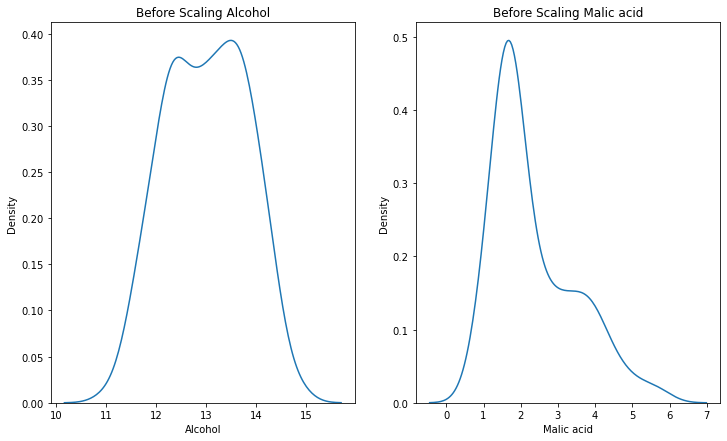

In [14]:
fig, (ax1,ax2)=plt.subplots(ncols=2,figsize=(12,7))
ax1.set_title("Before Scaling Alcohol")
sns.kdeplot(df["Alcohol"],ax=ax1)
ax2.set_title("Before Scaling Malic acid")
sns.kdeplot(df["Malic acid"],ax=ax2)

C:\Users\GR0012AU\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='Alcohol', ylabel='Malic acid'>

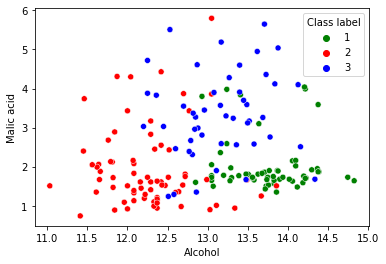

In [22]:
color_dict={1:"green",2:"red",3:"blue"}
sns.scatterplot(df["Alcohol"],df["Malic acid"],hue=df["Class label"],palette=color_dict)

In [23]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(df.iloc[:,1:],df["Class label"],test_size=0.3,random_state=0)

In [26]:
x_train

,Alcohol,Malic acid
22,13.71,1.86
108,12.22,1.29
175,13.27,4.28
145,13.16,3.57
71,13.86,1.51
...,...,...
103,11.82,1.72
67,12.37,1.17
117,12.42,1.61
47,13.90,1.68


In [27]:
x_test

,Alcohol,Malic acid
54,13.74,1.67
151,12.79,2.67
63,12.37,1.13
55,13.56,1.73
123,13.05,5.80
121,11.56,2.05
7,14.06,2.15
160,12.36,3.83
106,12.25,1.73
90,12.08,1.83


In [29]:
y_train

22     1
108    2
175    3
145    3
71     2
      ..
103    2
67     2
117    2
47     1
172    3
Name: Class label, Length: 124, dtype: int64

In [30]:
y_test

54     1
151    3
63     2
55     1
123    2
121    2
7      1
160    3
106    2
90     2
141    3
146    3
5      1
98     2
168    3
80     2
33     1
18     1
61     2
51     1
66     2
37     1
4      1
104    2
60     2
111    2
126    2
86     2
112    2
164    3
26     1
56     1
129    2
45     1
8      1
44     1
161    3
92     2
94     2
174    3
24     1
30     1
93     2
101    2
113    2
19     1
135    3
74     2
144    3
16     1
131    3
138    3
40     1
158    3
Name: Class label, dtype: int64

In [57]:
# x_scaled=x-min(x)/max(x)-min(x)

In [31]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
scaler.fit(x_train)
x_train_sc=scaler.transform(x_train)
x_test_sc=scaler.transform(x_test)

In [36]:
x_train_sc=pd.DataFrame(x_train_sc,columns=x_train.columns)
x_test_sc=pd.DataFrame(x_test_sc,columns=x_test.columns)
x_train_sc

,Alcohol,Malic acid
0,0.720430,0.203782
1,0.319892,0.084034
2,0.602151,0.712185
3,0.572581,0.563025
4,0.760753,0.130252
...,...,...
119,0.212366,0.174370
120,0.360215,0.058824
121,0.373656,0.151261
122,0.771505,0.165966


In [37]:
x_test

,Alcohol,Malic acid
54,13.74,1.67
151,12.79,2.67
63,12.37,1.13
55,13.56,1.73
123,13.05,5.80
121,11.56,2.05
7,14.06,2.15
160,12.36,3.83
106,12.25,1.73
90,12.08,1.83


<AxesSubplot:title={'center':'After Scaling Alcohol'}, xlabel='Alcohol', ylabel='Density'>

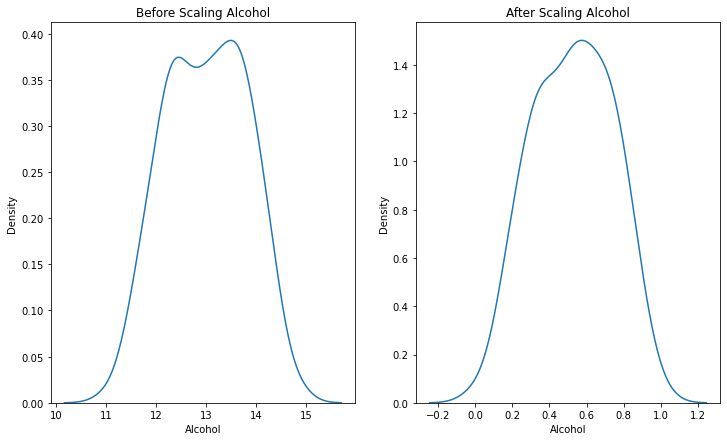

In [38]:
fig, (ax1,ax2)=plt.subplots(ncols=2,figsize=(12,7))
ax1.set_title("Before Scaling Alcohol")
sns.kdeplot(df["Alcohol"],ax=ax1)
ax2.set_title("After Scaling Alcohol")
sns.kdeplot(x_train_sc["Alcohol"],ax=ax2)

<AxesSubplot:title={'center':'After Scaling Alcohol'}, xlabel='Malic acid', ylabel='Density'>

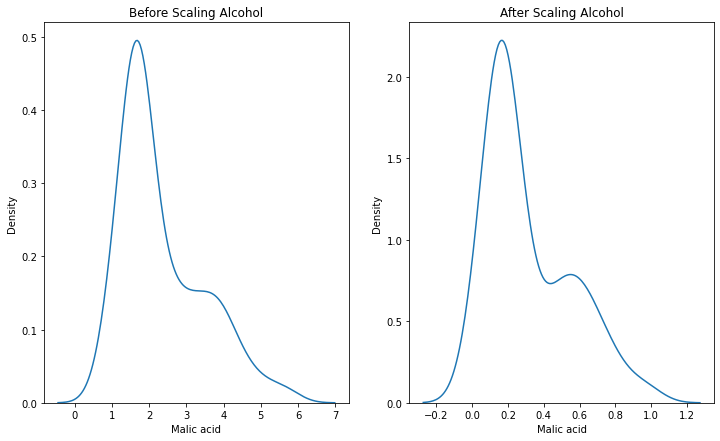

In [39]:
fig, (ax1,ax2)=plt.subplots(ncols=2,figsize=(12,7))
ax1.set_title("Before Scaling Alcohol")
sns.kdeplot(df["Malic acid"],ax=ax1)
ax2.set_title("After Scaling Alcohol")
sns.kdeplot(x_train_sc["Malic acid"],ax=ax2)

C:\Users\GR0012AU\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\Users\GR0012AU\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:title={'center':'After Scaling'}, xlabel='Alcohol', ylabel='Malic acid'>

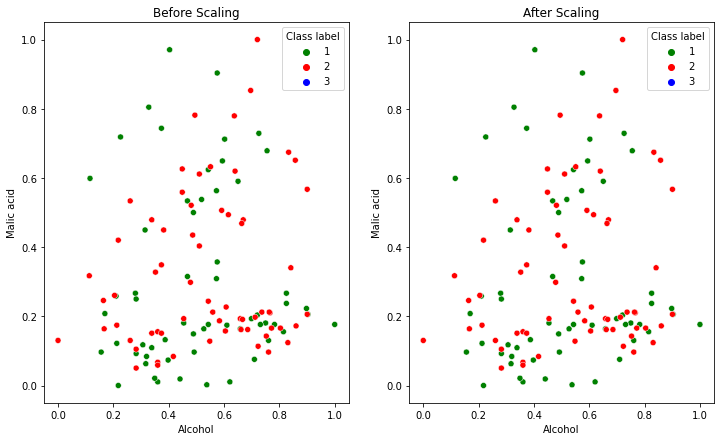

In [44]:
fig, (ax1,ax2)=plt.subplots(ncols=2,figsize=(12,7))
ax1.set_title("Before Scaling")
sns.scatterplot(x_train_sc["Alcohol"],x_train_sc["Malic acid"],hue=df["Class label"],palette=color_dict,ax=ax1)
ax2.set_title("After Scaling")
sns.scatterplot(x_train_sc["Alcohol"],x_train_sc["Malic acid"],hue=df["Class label"],palette=color_dict,ax=ax2)

C:\Users\GR0012AU\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\Users\GR0012AU\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:title={'center':'After Scaling'}, xlabel='Alcohol', ylabel='Malic acid'>

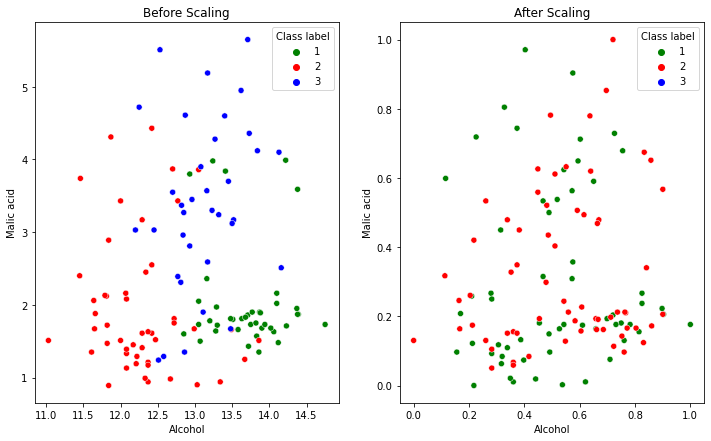

In [45]:
fig, (ax1,ax2)=plt.subplots(ncols=2,figsize=(12,7))
ax1.set_title("Before Scaling")
sns.scatterplot(x_train["Alcohol"],x_train["Malic acid"],hue=df["Class label"],palette=color_dict,ax=ax1)
ax2.set_title("After Scaling")
sns.scatterplot(x_train_sc["Alcohol"],x_train_sc["Malic acid"],hue=df["Class label"],palette=color_dict,ax=ax2)

In [46]:
# Mean Normalization
# MaxAbsScaling
# Robust Scaling

In [54]:
#  x_normalized = x−mean(x)/max(x)−min(x)

In [47]:
import numpy as np

data = np.array([1, 2, 3, 4, 5])
mean = np.mean(data)
range_ = np.max(data) - np.min(data)
normalized_data = (data - mean) / range_

print(normalized_data)

[-0.5  -0.25  0.    0.25  0.5 ]


In [55]:
# x_scaled= x/ max(x)

In [48]:
from sklearn.preprocessing import MaxAbsScaler
import numpy as np

data = np.array([[1, -2], [2, 0], [3, 4]])
scaler = MaxAbsScaler()
scaled_data = scaler.fit_transform(data)

print(scaled_data)

[[ 0.33333333 -0.5       ]
 [ 0.66666667  0.        ]
 [ 1.          1.        ]]


In [56]:
# x_scaled= x-meadian(x)/IQR
# IQR= Q3-Q1
# Q3= 75 percentile
# Q1= 25 percentile

In [49]:
from sklearn.preprocessing import RobustScaler
import numpy as np

data = np.array([[1], [2], [3], [100]])  # contains an outlier
scaler = RobustScaler()
scaled_data = scaler.fit_transform(data)

print(scaled_data)

[[-0.05882353]
 [-0.01960784]
 [ 0.01960784]
 [ 3.82352941]]


In [50]:
from sklearn.preprocessing import RobustScaler
sc=RobustScaler()
sc.fit(x_train)
x_train_scr=sc.transform(x_train)
x_test_scr=sc.transform(x_test)

In [51]:
x_train_scr=pd.DataFrame(x_train_scr,columns=x_train.columns)
x_test_scr=pd.DataFrame(x_test_scr,columns=x_test.columns)
x_train_scr

,Alcohol,Malic acid
0,0.524462,-0.015244
1,-0.641879,-0.362805
2,0.180039,1.460366
3,0.093933,1.027439
4,0.641879,-0.228659
...,...,...
119,-0.954990,-0.100610
120,-0.524462,-0.435976
121,-0.485323,-0.167683
122,0.673190,-0.125000


In [52]:
x_test_scr

,Alcohol,Malic acid
0,0.547945,-0.131098
1,-0.195695,0.478659
2,-0.524462,-0.460366
3,0.407045,-0.094512
4,0.007828,2.387195
5,-1.158513,0.100610
6,0.798434,0.161585
7,-0.532290,1.185976
8,-0.618395,-0.094512
9,-0.751468,-0.033537
